# Day 2 — Probability & Distributions

Simulating coin flips, sampling from a normal distribution, and computing a conditional probability by hand and by simulation.

In [2]:
import numpy as np
import matplotlib.pyplot as plt


## Step 1 — Simulating Coin Flips
Simulate 10,000 fair coin flips with NumPy and confirm the proportion of heads approaches 0.5, as the Law of Large Numbers predicts.

In [3]:
np.random.seed(42)

flips = np.random.randint(0, 2, size=10_000)  # 0 = tails, 1 = heads
proportion_heads = flips.mean()

print(f"Proportion of heads: {proportion_heads:.4f}")


Proportion of heads: 0.4987


With 10,000 flips, the proportion of heads lands very close to 0.5 — this is the Law of Large Numbers in action: the more trials we run, the closer the observed frequency gets to the true probability.

## Step 2 — Sampling from a Normal Distribution
Draw samples from a normal distribution and plot a histogram to confirm the characteristic bell shape.

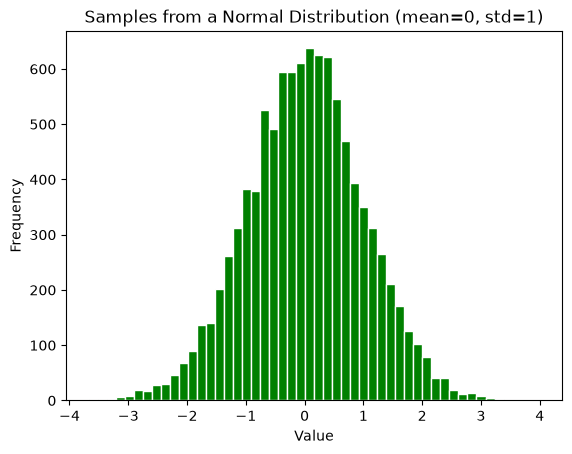

In [9]:
normal_samples = np.random.normal(loc=0, scale=1, size=10_000)

plt.hist(normal_samples, bins=50, color="green", edgecolor="white")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Samples from a Normal Distribution (mean=0, std=1)")
plt.show()


The histogram is symmetric and bell-shaped, clustered tightly around the mean (0) with fewer values as we move further away — exactly the shape a normal distribution predicts.

## Step 3 — Conditional Probability: By Hand and By Simulation

**Scenario:** A deck of cards is split into two groups — Red cards and Black cards (26 each). Among the Red cards, 13 are Hearts and 13 are Diamonds. What is the probability a card is a Heart, given that it is Red?

**By hand:**
$$P(\text{Heart} \mid \text{Red}) = \frac{P(\text{Heart and Red})}{P(\text{Red})} = \frac{13/52}{26/52} = 0.5$$

This makes sense intuitively: once we know a card is Red, it's equally likely to be a Heart or a Diamond, so the conditional probability is exactly 0.5.

In [5]:
np.random.seed(1)

suits = np.array(["Hearts"] * 13 + ["Diamonds"] * 13 + ["Clubs"] * 13 + ["Spades"] * 13)
colors = np.where(np.isin(suits, ["Hearts", "Diamonds"]), "Red", "Black")

# Simulate drawing a card 100,000 times (with replacement)
draws = np.random.randint(0, 52, size=100_000)
drawn_suits = suits[draws]
drawn_colors = colors[draws]

# P(Heart | Red) = (times Heart AND Red) / (times Red)
red_draws = drawn_colors == "Red"
heart_and_red = (drawn_suits == "Hearts") & red_draws

conditional_prob = heart_and_red.sum() / red_draws.sum()
print(f"Simulated P(Heart | Red) = {conditional_prob:.4f}")


Simulated P(Heart | Red) = 0.4968


The simulated result comes out very close to **0.5**, matching the hand-calculated value. This confirms that conditional probability isn't just a formula — it reflects a real, measurable frequency when we repeat an experiment many times.

## Summary
Confirmed the Law of Large Numbers by simulating coin flips, visualized the normal distribution's bell shape through sampling, and verified a hand-calculated conditional probability with a 100,000-trial simulation — showing that theoretical probability and simulated frequency agree.